# BridgeData V2 - Frame Loading & Scene Filtering


Streams BridgeData V2 episodes from the public GCS mirror, extracts initial
frames + instructions + early-motion ground truth, filters to multi-object /
spatial scenes via a text heuristic, and caches the survivors to Drive.

This notebook uses only the TensorFlow/TFDS stack. The model is never loaded
here. 


## 1. Mount Drive 

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
CACHE_DIR = '/content/drive/MyDrive/openvla_cache/bridge_multiobj'
os.makedirs(CACHE_DIR, exist_ok=True)
print('cache ->', CACHE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cache -> /content/drive/MyDrive/openvla_cache/bridge_multiobj


## 2. Get the code and import `data.py`

Clones the repo fresh and clears the import cache (a kernel that has re-cloned
during a session otherwise caches a stale 'module not found').


In [2]:
import sys, shutil, os, glob, importlib
REPO_DIR = '/content/ECS8056'
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
!git clone -q https://github.com/LewisTL/ECS8056.git {REPO_DIR}

model_dir = os.path.dirname(glob.glob(os.path.join(REPO_DIR, '**', 'data.py'), recursive=True)[0])
if model_dir not in sys.path:
    sys.path.insert(0, model_dir)
sys.modules.pop('data', None)
importlib.invalidate_caches()

import data
from data import stream_episodes, classify_instruction, cache_records, load_manifest
print('imported data.py from', model_dir)

imported data.py from /content/ECS8056


## 3. Stream a small slice and inspect extraction

Pulls a handful of episodes to confirm the keys resolve and the early-motion
ground truth is non-zero (the first transition is a recorded no-op and is
skipped).


In [3]:
import numpy as np
sample = list(stream_episodes(n=8))
for r in sample:
    print(f'ep {r.episode_index:>5} | steps={r.num_steps:>3} | gt_xyz={np.round(r.gt_vector[:3], 4)} | {r.instruction}')

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

AttributeError: module 'tensorflow_datasets' has no attribute 'builder_from_directory'

## 4. Filter yield on the slice

Reports how the text heuristic tags the sampled instructions. `has_spatial` is
the primary probe target; `has_transfer` is the broader multi-object pool.


In [ ]:
for r in sample:
    t = r.tags
    print(f'multi={t.is_multi_object!s:5} spatial={t.has_spatial!s:5} '
          f'transfer={t.has_transfer!s:5} [{t.matched or "-"}] {r.instruction}')

multi=True  spatial=True  transfer=False [left|to the left] Place the can to the left of the pot.
multi=True  spatial=True  transfer=True  [front|next to|in front of|transfer] Move the silver pot from in front of the red can, to next to the blue towel at the front edge of the table.
multi=True  spatial=True  transfer=False [front] Slide the cloth diagonally to the front of the spoon
multi=True  spatial=False transfer=True  [transfer] put knife on cutting board
multi=True  spatial=True  transfer=False [right] Move the kadai and place it at the right edge of the table.
multi=True  spatial=False transfer=True  [transfer] Put the banana on the green cloth
multi=True  spatial=True  transfer=True  [bottom|right|transfer] Put the napkin in the bottom right hand corner of the table.
multi=True  spatial=False transfer=True  [transfer] place the silver pot on the yellow napkin


## 5. R2 read - multi-object yield over a larger slice

Scales the stream up to estimate how many candidate scenes BridgeData V2 yields.
Raise `N` for a tighter estimate; streaming is sequential, so larger N is slower.
A low spatial yield here is the early signal to supplement with the Open
X-Embodiment subset held in reserve.


In [ ]:
N = 300   # scale up/down as session time allows
counts = {'total': 0, 'multi': 0, 'spatial': 0, 'transfer': 0}
survivors = []
for r in stream_episodes(n=N):
    counts['total'] += 1
    if r.tags.is_multi_object: counts['multi'] += 1; survivors.append(r)
    if r.tags.has_spatial:     counts['spatial'] += 1
    if r.tags.has_transfer:    counts['transfer'] += 1

print(counts)
print(f"multi-object: {counts['multi']/counts['total']:.1%} | "
      f"spatial: {counts['spatial']/counts['total']:.1%} | "
      f"transfer: {counts['transfer']/counts['total']:.1%}")

{'total': 300, 'multi': 224, 'spatial': 119, 'transfer': 140}
multi-object: 74.7% | spatial: 39.7% | transfer: 46.7%


## 6. Cache survivors to Drive

Persists only the filtered frames plus a manifest CSV (instruction, tags,
ground-truth vector, frame path). The cached set is the compact, reproducible
input for the evaluation notebook — no re-streaming required.


In [ ]:
manifest_path = cache_records(survivors, CACHE_DIR, multi_object_only=True)
print('manifest:', manifest_path)

[cache_records] wrote 224 frames + manifest to /content/drive/MyDrive/openvla_cache/bridge_multiobj
manifest: /content/drive/MyDrive/openvla_cache/bridge_multiobj/manifest.csv


## 7. Verify the cache - read back and view samples

Manual review of a few frames is the check on the text heuristic before the
evaluation set is finalised (plan: programmatic filter, manual verification).


224 cached scenes


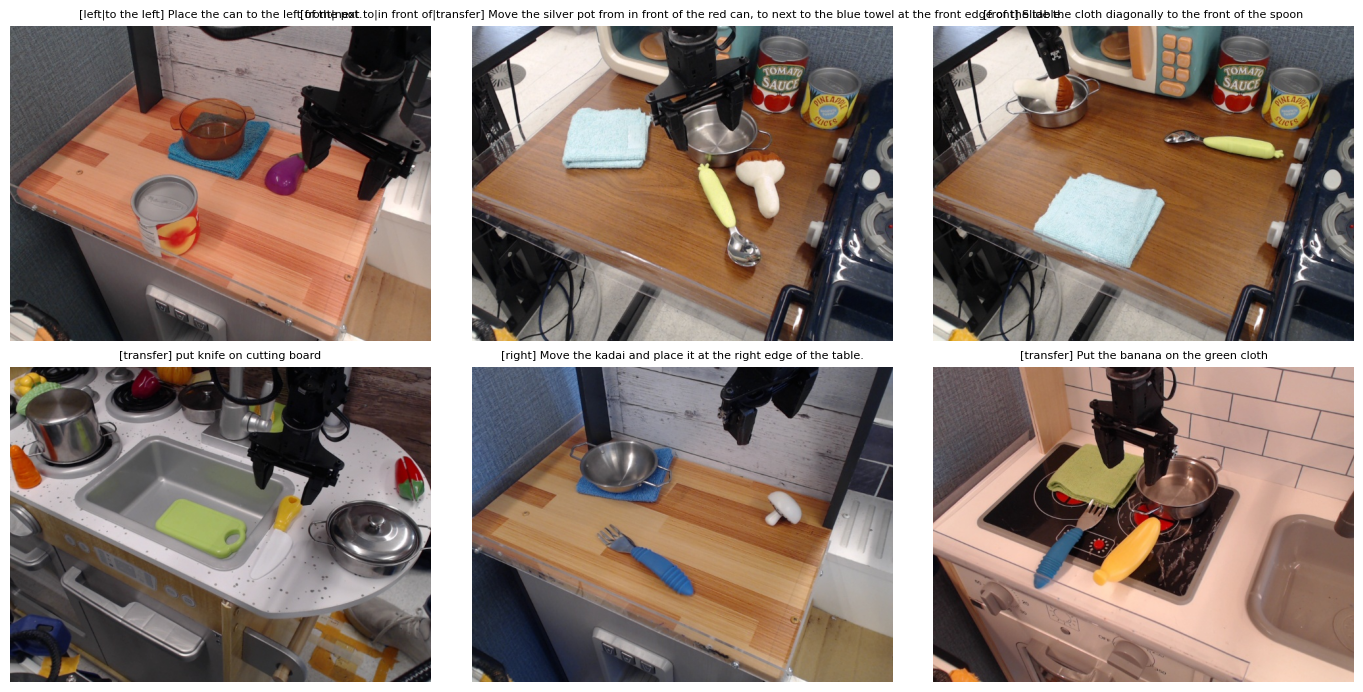

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
rows = load_manifest(CACHE_DIR)
print(f'{len(rows)} cached scenes')

show = rows[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, row in zip(axes.ravel(), show):
    img = Image.open(os.path.join(CACHE_DIR, row['image_path']))
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"[{row['matched_terms']}] {row['instruction']}", fontsize=8)
for ax in axes.ravel()[len(show):]:
    ax.axis('off')
plt.tight_layout(); plt.show()